In [ ]:
n

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")


In [4]:
df = pd.read_csv("../data/Attendance_Prediction.csv")
df.head()

,student_id,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,200.99,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,200.99,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,200.99,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,200.99,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,200.99,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work


In [5]:
df.shape

(20000, 15)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           20000 non-null  float64
 1   age                  20000 non-null  int64  
 2   gender               20000 non-null  object 
 3   course               20000 non-null  object 
 4   year                 20000 non-null  object 
 5   parent_education     20000 non-null  object 
 6   internet_access      20000 non-null  object 
 7   hostel_resident      20000 non-null  object 
 8   class_type           20000 non-null  object 
 9   weather              20000 non-null  object 
 10  study_hours          20000 non-null  float64
 11  sleep_hours          20000 non-null  float64
 12  travel_time_minutes  20000 non-null  int64  
 13  attendance           20000 non-null  int64  
 14  absence_reason       20000 non-null  object 
dtypes: float64(3), int64(3), object(9)
m

In [7]:
df.describe()


,student_id,age,study_hours,sleep_hours,travel_time_minutes,attendance
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,20.473300,2.989558,7.013978,46.978100,0.516350
std,5770.211372,2.284458,1.727470,1.739200,24.583225,0.499745
min,200.990000,17.000000,0.050000,4.060000,5.000000,0.000000
25%,5000.750000,18.000000,1.480000,5.500000,26.000000,0.000000
50%,10000.500000,20.000000,2.980000,7.010000,47.000000,1.000000
75%,15000.250000,22.000000,4.480000,8.540000,68.000000,1.000000
max,19800.010000,24.000000,5.930000,9.940000,89.000000,1.000000


In [8]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'parent_education',
       'internet_access', 'hostel_resident', 'class_type', 'weather',
       'study_hours', 'sleep_hours', 'travel_time_minutes', 'attendance',
       'absence_reason'],
      dtype='object')

In [9]:
df.isnull().sum()

student_id             0
age                    0
gender                 0
course                 0
year                   0
parent_education       0
internet_access        0
hostel_resident        0
class_type             0
weather                0
study_hours            0
sleep_hours            0
travel_time_minutes    0
attendance             0
absence_reason         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df = df.drop("student_id", axis=1)

In [13]:
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
df["study_sleep_ratio"] = (
    df["study_hours"] /
    df["sleep_hours"]
)

In [15]:
df["travel_category"] = pd.cut(
    df["travel_time_minutes"],
    bins=[0,30,60,90],
    labels=["Near","Medium","Far"]
)

In [16]:
scaler = StandardScaler()

num_cols = [
    "age",
    "study_hours",
    "sleep_hours",
    "travel_time_minutes"
]

df[num_cols] = scaler.fit_transform(df[num_cols])

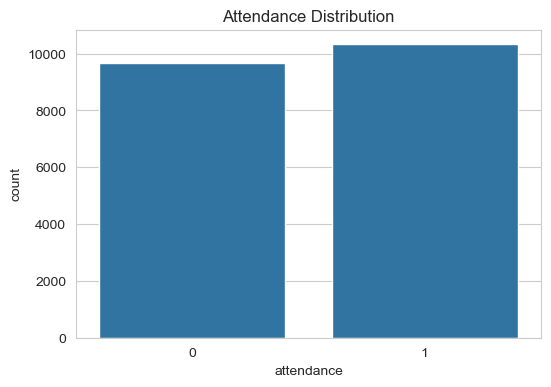

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="attendance",
    data=df
)

plt.title("Attendance Distribution")

plt.savefig("../images/attendance_distribution.png")

plt.show()

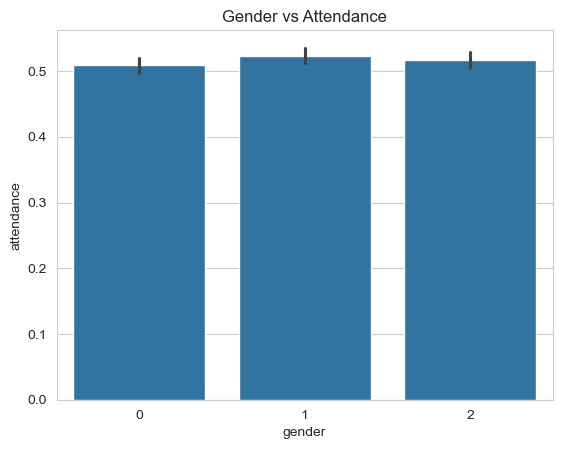

In [20]:
sns.barplot(
    x="gender",
    y="attendance",
    data=df
)

plt.title("Gender vs Attendance")
plt.show()

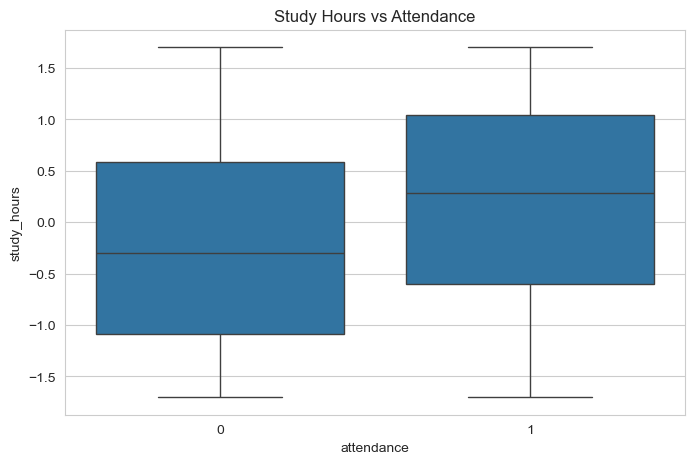

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="attendance",
    y="study_hours",
    data=df
)

plt.title("Study Hours vs Attendance")

plt.savefig("../images/study_hours_vs_attendance.png",
            bbox_inches="tight")

plt.show()

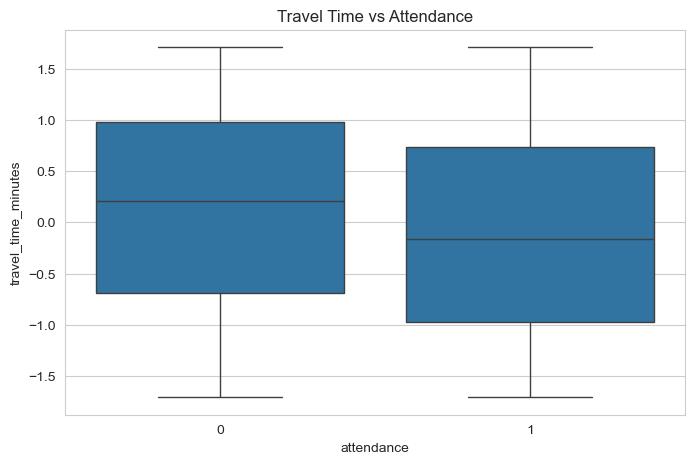

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="attendance",
    y="travel_time_minutes",
    data=df
)

plt.title("Travel Time vs Attendance")

plt.savefig("../images/travel_time_vs_attendance.png",
            bbox_inches="tight")

plt.show()

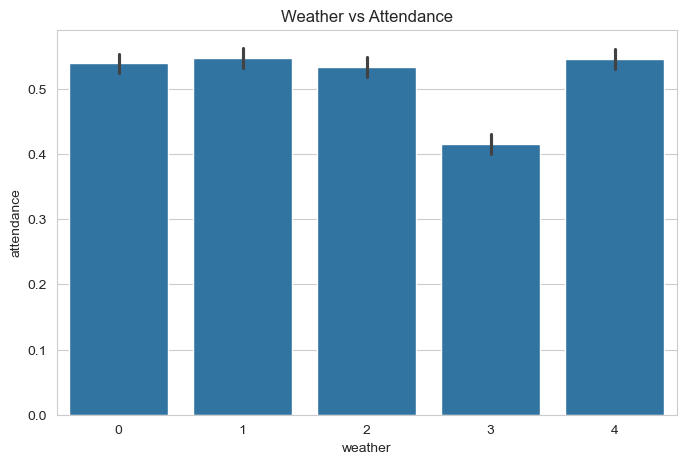

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="weather",
    y="attendance",
    data=df
)

plt.title("Weather vs Attendance")

plt.savefig("../images/weather_vs_attendance.png",
            bbox_inches="tight")

plt.show()

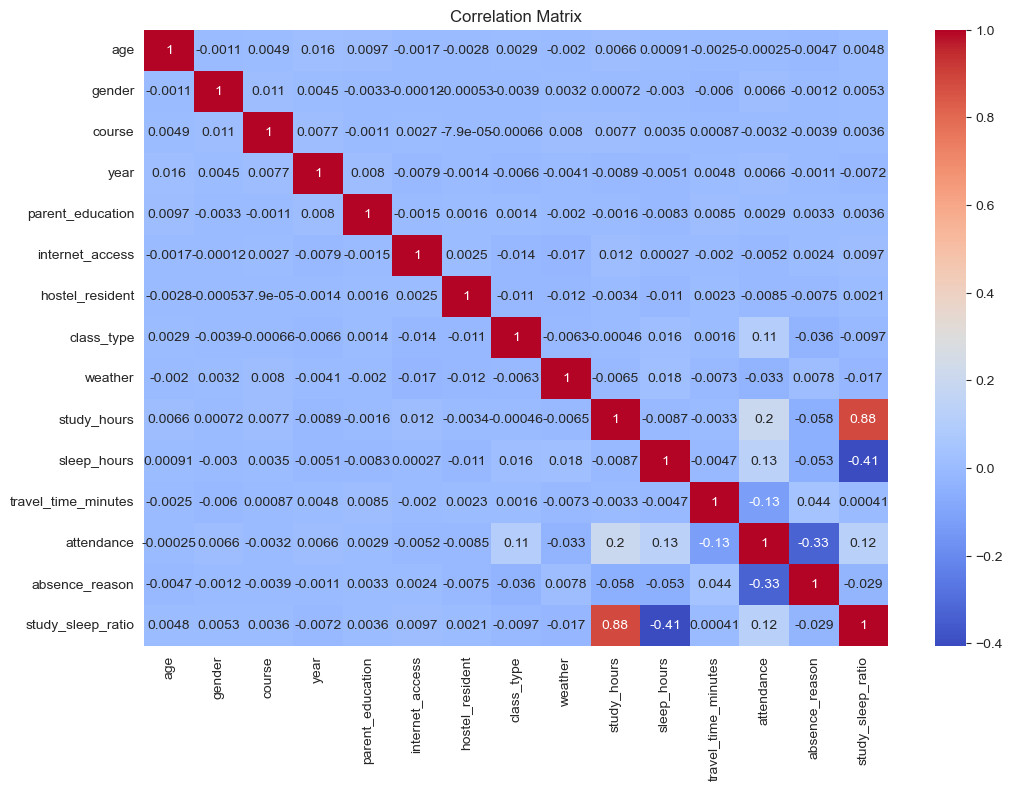

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()